In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Data and preprocessing
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif

# Models
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

# Interpretability
import shap
import lime.lime_tabular

print("Libraries imported successfully!")




2025-11-28 19:24:00.637883: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Libraries imported successfully!


In [2]:
# Load breast cancer dataset
print("Loading Wisconsin Breast Cancer Dataset...")

# Fetch dataset
dataset = fetch_ucirepo(id=17)
X = dataset.data.features
y = dataset.data.targets

print(f"Dataset loaded - Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Target classes: {y.nunique().iloc[0]}")
print(f"Missing values: {X.isnull().sum().sum()}")

# Target distribution
target_counts = y.value_counts()
print(f"\nTarget distribution:")
for label, count in target_counts.items():
    print(f"  {label}: {count} ({count/len(y)*100:.1f}%)")



Loading Wisconsin Breast Cancer Dataset...
Dataset loaded - Samples: 569, Features: 30
Target classes: 2
Missing values: 0

Target distribution:
  ('B',): 357 (62.7%)
  ('M',): 212 (37.3%)
Dataset loaded - Samples: 569, Features: 30
Target classes: 2
Missing values: 0

Target distribution:
  ('B',): 357 (62.7%)
  ('M',): 212 (37.3%)


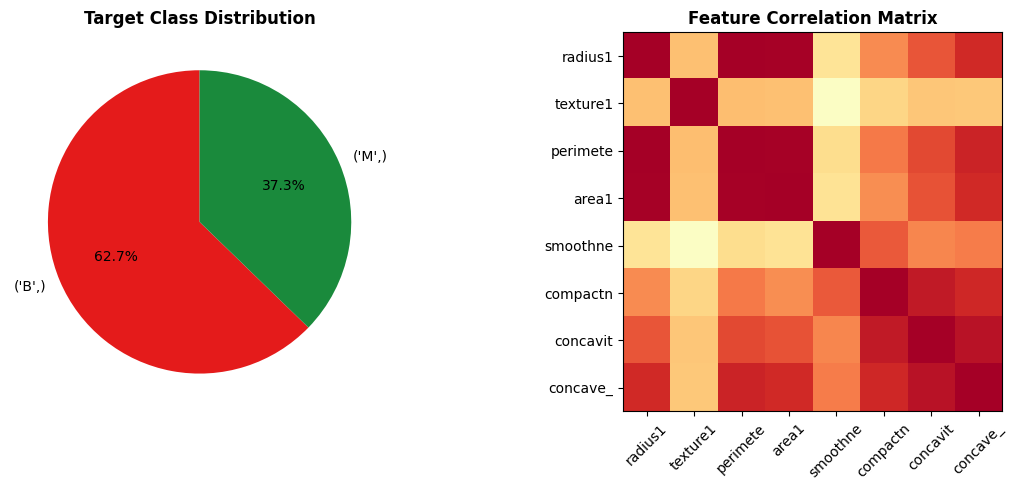

In [3]:
# Basic dataset visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Target distribution
labels = target_counts.index
sizes = target_counts.values
colors = ["#E41B1B", "#1A8A3C"]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Target Class Distribution', fontweight='bold')

top_features_corr = X.iloc[:, :8]
corr_matrix = top_features_corr.corr()
im = axes[1].imshow(corr_matrix.values, cmap='RdYlBu_r', vmin=-1, vmax=1)
axes[1].set_title('Feature Correlation Matrix', fontweight='bold')
axes[1].set_xticks(range(len(corr_matrix.columns)))
axes[1].set_xticklabels([col[:8] for col in corr_matrix.columns], rotation=45)
axes[1].set_yticks(range(len(corr_matrix.columns)))
axes[1].set_yticklabels([col[:8] for col in corr_matrix.columns])

plt.tight_layout()
plt.show()

In [4]:
# Data preprocessing
print("Preprocessing data...")

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y.values.ravel())

# Feature selection - select top 15 features
feature_selector = SelectKBest(score_func=f_classif, k=15)
X_selected = feature_selector.fit_transform(X, y_encoded)

# Get selected feature names
selected_indices = feature_selector.get_support(indices=True)
selected_features = X.columns[selected_indices].tolist()
print(f"Selected {len(selected_features)} features")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


Preprocessing data...
Selected 15 features


Training: 455 samples, Testing: 114 samples


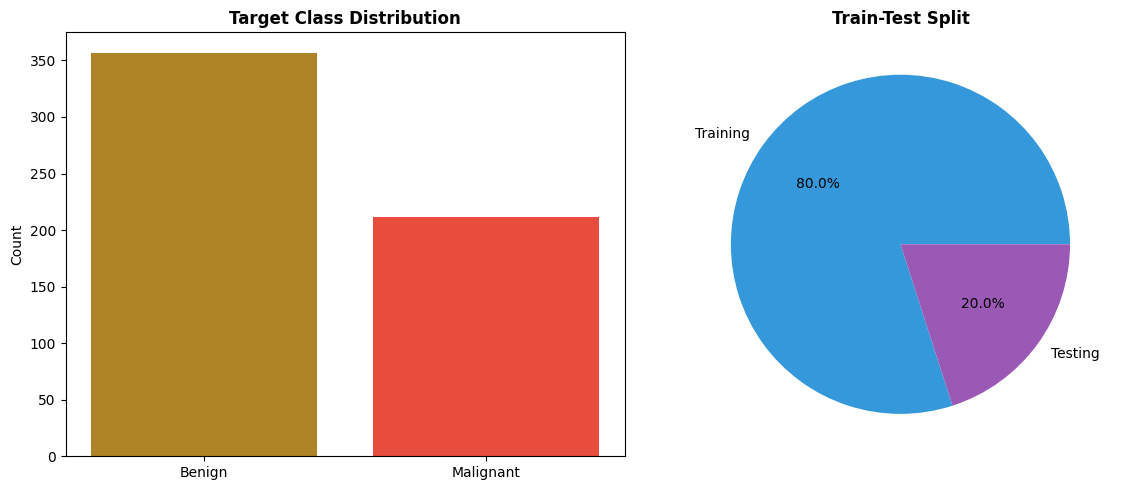

In [5]:
print(f"Training: {X_train.shape[0]} samples, Testing: {X_test.shape[0]} samples")

# Simple preprocessing visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Target distribution
labels = ['Benign', 'Malignant']
counts = [np.sum(y_encoded == 0), np.sum(y_encoded == 1)]
axes[0].bar(labels, counts, color=["#AF8427", '#E74C3C'])
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

# Train-test split
split_labels = ['Training', 'Testing']
split_sizes = [len(X_train), len(X_test)]
axes[1].pie(split_sizes, labels=split_labels, autopct='%1.1f%%', colors=['#3498DB', '#9B59B6'])
axes[1].set_title('Train-Test Split', fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
# Build deep learning model
def build_deep_learning_model(input_shape):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_shape,)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), 
                 loss='binary_crossentropy', 
                 metrics=['accuracy'])
    return model

# Initialize Deep Learning model
model = build_deep_learning_model(X_train.shape[1])

In [7]:
# Train Deep Learning model
print("Training Deep Learning model...")

history = model.fit(X_train, y_train, 
                   epochs=50, 
                   batch_size=32, 
                   validation_split=0.2, 
                   verbose=0)

# Make predictions
y_pred_proba = model.predict(X_test, verbose=0).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

# Store results
results = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'AUC': auc
}



Training Deep Learning model...


In [8]:
# Display model performance
print("\nDeep Learning Model Performance:")
for metric, value in results.items():
    print(f"{metric}: {value:.4f}")

model_name = 'Deep Learning'
best_model = model


Deep Learning Model Performance:
Accuracy: 0.9825
Precision: 1.0000
Recall: 0.9524
F1-Score: 0.9756
AUC: 1.0000


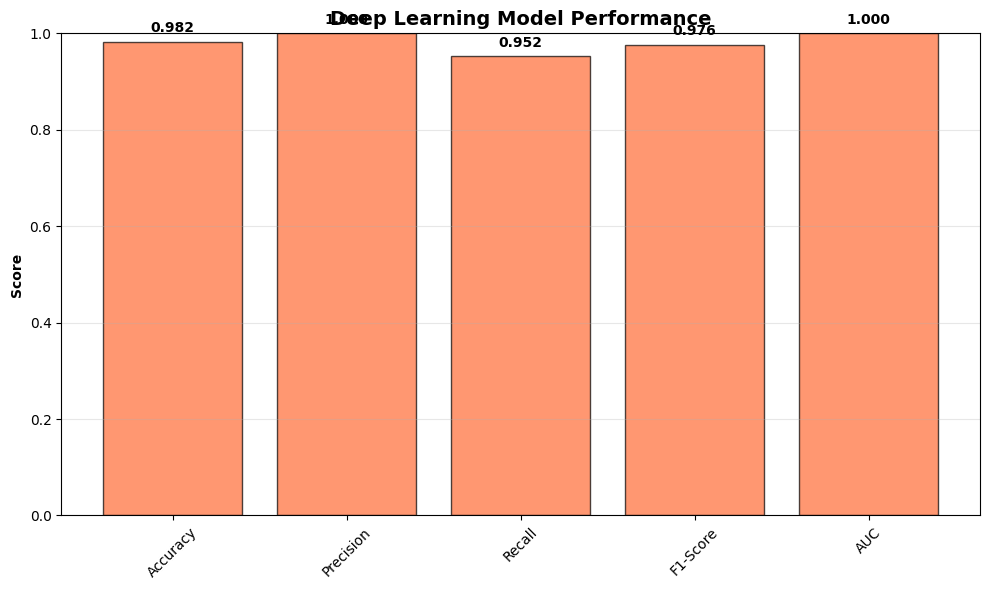

In [9]:
# Model Performance Visualization
plt.figure(figsize=(10, 6))

metrics = list(results.keys())
values = list(results.values())

plt.bar(metrics, values, color='#FF6B35', alpha=0.7, edgecolor='black')
plt.ylim(0, 1)
plt.ylabel('Score', fontweight='bold')
plt.title('Deep Learning Model Performance', fontweight='bold', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)

# Add value labels on bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()



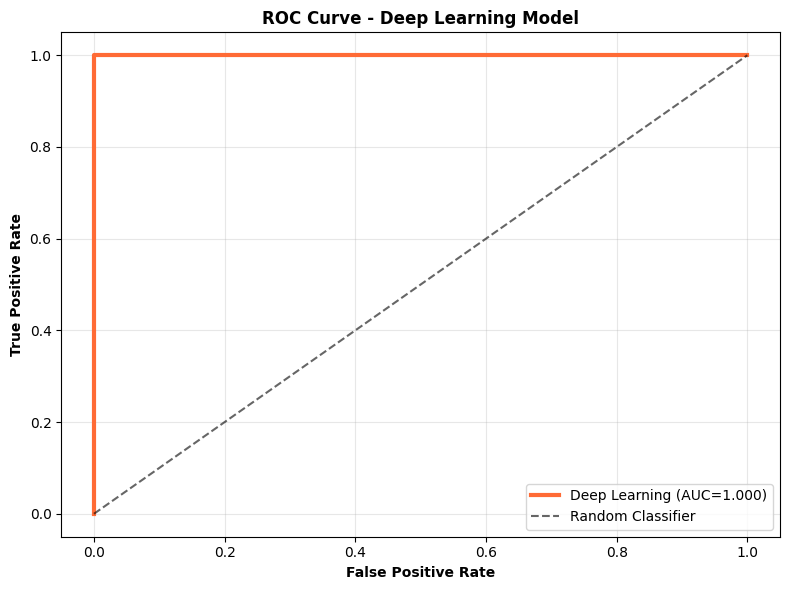

In [10]:
# ROC Curve Analysis
plt.figure(figsize=(8, 6))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'Deep Learning (AUC={auc_score:.3f})', 
         linewidth=3, color='#FF6B35')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Random Classifier')
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('ROC Curve - Deep Learning Model', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

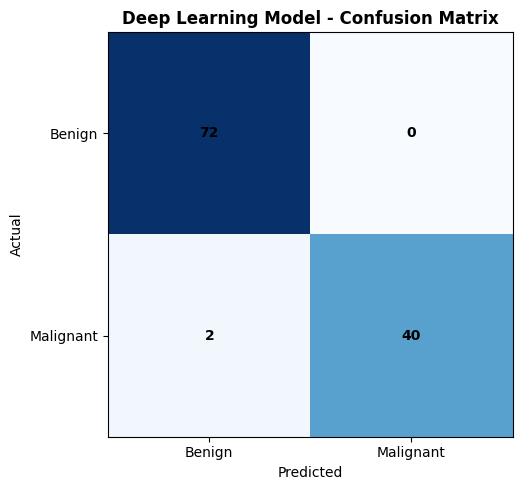

In [11]:
# Confusion Matrix
plt.figure(figsize=(6, 5))

y_pred_best = (model.predict(X_test, verbose=0).flatten() > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_best)

im = plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Deep Learning Model - Confusion Matrix', fontweight='bold')

# Add text annotations
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center", fontweight='bold')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.gca().set_xticklabels(['Benign', 'Malignant'])
plt.gca().set_yticklabels(['Benign', 'Malignant'])
plt.tight_layout()
plt.show()

In [12]:
print(f"\nDeep Learning Model Performance:")
for metric, value in results.items():
    print(f"{metric}: {value:.4f}")


Deep Learning Model Performance:
Accuracy: 0.9825
Precision: 1.0000
Recall: 0.9524
F1-Score: 0.9756
AUC: 1.0000



SHAP Analysis for Deep Learning Model


  0%|          | 0/20 [00:00<?, ?it/s]

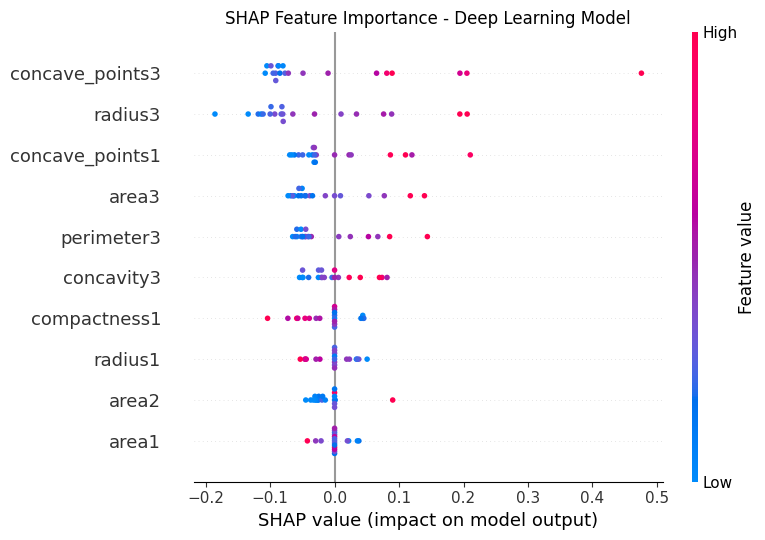

In [13]:
# SHAP Analysis for Deep Learning Model
print(f"\nSHAP Analysis for Deep Learning Model")

# Select subset of test data for SHAP analysis
X_shap = X_test[:20]

try:
    # For deep learning, use KernelExplainer
    def dl_predict_wrapper(X):
        return model.predict(X, verbose=0).flatten()
    
    explainer = shap.KernelExplainer(dl_predict_wrapper, X_train[:100])
    shap_values = explainer.shap_values(X_shap, nsamples=100)
    
    # Create SHAP plots
    plt.figure(figsize=(12, 8))
    
    # Summary plot
    shap.summary_plot(shap_values, X_shap, feature_names=selected_features, 
                     show=False, max_display=10)
    plt.title('SHAP Feature Importance - Deep Learning Model')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"SHAP analysis encountered an error: {e}")


LIME Analysis for Deep Learning Model


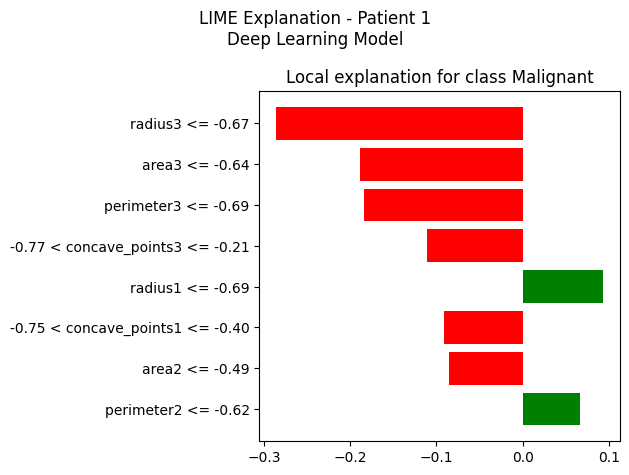


LIME Explanation for Patient 1:
  radius3 <= -0.67: -0.2866
  area3 <= -0.64: -0.1884
  perimeter3 <= -0.69: -0.1839
  -0.77 < concave_points3 <= -0.21: -0.1107
  radius1 <= -0.69: 0.0936
  -0.75 < concave_points1 <= -0.40: -0.0915
  area2 <= -0.49: -0.0858
  perimeter2 <= -0.62: 0.0663


In [14]:


# LIME Analysis for Deep Learning Model
print(f"\nLIME Analysis for Deep Learning Model")

try:
    # Create LIME explainer
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train,
        feature_names=selected_features,
        class_names=['Benign', 'Malignant'],
        mode='classification'
    )
    
    # Explain a single prediction
    patient_idx = 0
    patient_data = X_test[patient_idx]
    
    # Create prediction function for LIME
    def predict_fn(X):
        predictions = model.predict(X, verbose=0).flatten()
        return np.column_stack([1 - predictions, predictions])
    
    # Get explanation
    explanation = lime_explainer.explain_instance(
        patient_data, 
        predict_fn, 
        num_features=8
    )
    
    # Show explanation
    fig = explanation.as_pyplot_figure()
    fig.suptitle(f'LIME Explanation - Patient {patient_idx+1}\nDeep Learning Model')
    plt.tight_layout()
    plt.show()
    
    # Print explanation details
    print(f"\nLIME Explanation for Patient {patient_idx+1}:")
    for feature, importance in explanation.as_list():
        print(f"  {feature}: {importance:.4f}")

except Exception as e:
    print(f"LIME analysis encountered an error: {e}")



Deep Learning Model Feature Importance:
Feature importance based on first layer weights:
Top 10 most important features (by weight magnitude):
  radius3: 0.1873
  concave_points3: 0.1636
  perimeter3: 0.1583
  concave_points1: 0.1553
  radius1: 0.1543
  concavity3: 0.1476
  perimeter2: 0.1460
  area3: 0.1460
  area1: 0.1414
  area2: 0.1408


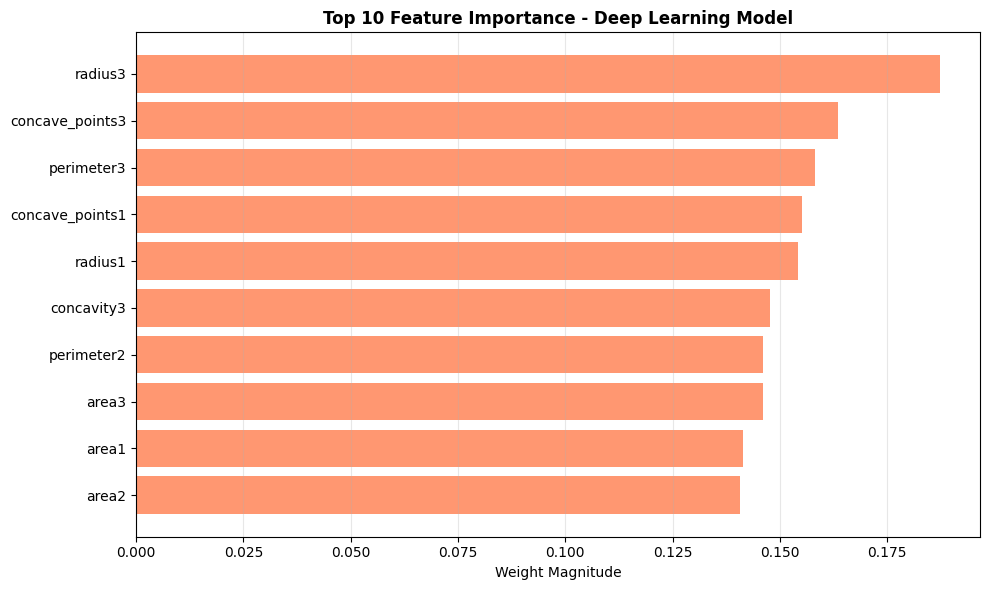

In [15]:
# Deep Learning Model Feature Importance
print(f"\nDeep Learning Model Feature Importance:")

# For deep learning models, use weight magnitudes from first layer
print("Feature importance based on first layer weights:")
first_layer_weights = model.layers[0].get_weights()[0]
weight_magnitudes = np.mean(np.abs(first_layer_weights), axis=1)

feature_imp_df = pd.DataFrame({
    'feature': selected_features,
    'importance': weight_magnitudes
}).sort_values('importance', ascending=False)

print("Top 10 most important features (by weight magnitude):")
for idx, row in feature_imp_df.head(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")
    
# Plot feature importance
plt.figure(figsize=(10, 6))
top_features = feature_imp_df.head(10)
plt.barh(range(len(top_features)), top_features['importance'], color='#FF6B35', alpha=0.7)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Weight Magnitude')
plt.title('Top 10 Feature Importance - Deep Learning Model', fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [16]:
# Clinical prediction simulation
print("Clinical Prediction Simulation")

def predict_patient_case(model, patient_features, patient_id):
    # Get prediction from Deep Learning model
    prediction_proba_single = model.predict(patient_features.reshape(1, -1), verbose=0)[0][0]
    prediction = 1 if prediction_proba_single > 0.5 else 0
    prediction_proba = [1 - prediction_proba_single, prediction_proba_single]
    
    # Clinical interpretation
    diagnosis = "MALIGNANT" if prediction == 1 else "BENIGN"
    confidence = max(prediction_proba)
    malignant_prob = prediction_proba[1]
    
    # Risk assessment
    if malignant_prob >= 0.8:
        risk_level = "HIGH RISK"
        recommendation = "Immediate biopsy recommended"
    elif malignant_prob >= 0.6:
        risk_level = "MODERATE-HIGH RISK" 
        recommendation = "Biopsy within 2 weeks"
    elif malignant_prob >= 0.4:
        risk_level = "MODERATE RISK"
        recommendation = "Close monitoring recommended"
    else:
        risk_level = "LOW RISK"
        recommendation = "Routine follow-up"
    
    print(f"\nPatient {patient_id} Assessment:")
    print(f"   Diagnosis: {diagnosis}")
    print(f"   Confidence: {confidence:.1%}")
    print(f"   Risk Level: {risk_level}")
    print(f"   Recommendation: {recommendation}")
    print(f"   Malignant Probability: {malignant_prob:.1%}")
    print(f"   Benign Probability: {prediction_proba[0]:.1%}")
    
    return {
        'diagnosis': diagnosis,
        'confidence': confidence,
        'malignant_prob': malignant_prob,
        'risk_level': risk_level,
        'recommendation': recommendation
    }


Clinical Prediction Simulation


In [17]:

# Simulate multiple patient cases
print(f"Simulating patient cases using Deep Learning model...")

simulation_results = []
num_cases = 5

for i in range(num_cases):
    patient_data = X_test[i]
    actual_label = y_test[i]
    
    result = predict_patient_case(model, patient_data, i+1)
    result['actual'] = "MALIGNANT" if actual_label == 1 else "BENIGN"
    result['correct'] = result['diagnosis'] == result['actual']
    
    simulation_results.append(result)

# Summary of simulation
print(f"\nSimulation Summary:")
correct_predictions = sum(1 for r in simulation_results if r['correct'])
print(f"   Correct predictions: {correct_predictions}/{num_cases}")
print(f"   Accuracy: {correct_predictions/num_cases:.1%}")

high_risk_cases = sum(1 for r in simulation_results if 'HIGH' in r['risk_level'])
print(f"   High risk cases identified: {high_risk_cases}")



Simulating patient cases using Deep Learning model...

Patient 1 Assessment:
   Diagnosis: BENIGN
   Confidence: 99.9%
   Risk Level: LOW RISK
   Recommendation: Routine follow-up
   Malignant Probability: 0.1%
   Benign Probability: 99.9%

Patient 2 Assessment:
   Diagnosis: MALIGNANT
   Confidence: 100.0%
   Risk Level: HIGH RISK
   Recommendation: Immediate biopsy recommended
   Malignant Probability: 100.0%
   Benign Probability: 0.0%

Patient 3 Assessment:
   Diagnosis: BENIGN
   Confidence: 98.0%
   Risk Level: LOW RISK
   Recommendation: Routine follow-up
   Malignant Probability: 2.0%
   Benign Probability: 98.0%

Patient 4 Assessment:
   Diagnosis: MALIGNANT
   Confidence: 86.3%
   Risk Level: HIGH RISK
   Recommendation: Immediate biopsy recommended
   Malignant Probability: 86.3%
   Benign Probability: 13.7%

Patient 5 Assessment:
   Diagnosis: BENIGN
   Confidence: 99.3%
   Risk Level: LOW RISK
   Recommendation: Routine follow-up
   Malignant Probability: 0.7%
   Benign Pr

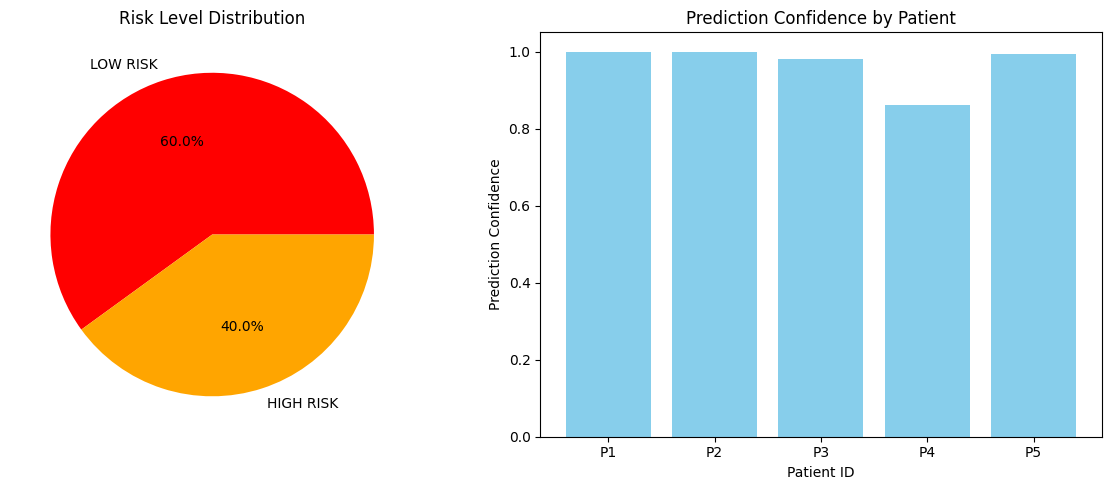

In [18]:
# Visualization of simulation results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Risk level distribution
risk_levels = [r['risk_level'] for r in simulation_results]
risk_counts = pd.Series(risk_levels).value_counts()
colors = ['red', 'orange', 'yellow', 'lightgreen'][:len(risk_counts)]
axes[0].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%', colors=colors)
axes[0].set_title('Risk Level Distribution')

# Confidence distribution
confidences = [r['confidence'] for r in simulation_results]
axes[1].bar(range(len(confidences)), confidences, color='skyblue')
axes[1].set_xlabel('Patient ID')
axes[1].set_ylabel('Prediction Confidence')
axes[1].set_title('Prediction Confidence by Patient')
axes[1].set_xticks(range(len(confidences)))
axes[1].set_xticklabels([f'P{i+1}' for i in range(len(confidences))])

plt.tight_layout()
plt.show()

In [19]:
# Save the trained model and preprocessing components
import joblib

# Save the deep learning model
model_filename = 'breast_cancer_clinical_model.h5'
model.save(model_filename)

# Save the scaler for future data preprocessing
scaler_filename = 'breast_cancer_scaler.pkl'
joblib.dump(scaler, scaler_filename)

# Save the feature selector
selector_filename = 'breast_cancer_feature_selector.pkl'
joblib.dump(feature_selector, selector_filename)

# Save the label encoder
encoder_filename = 'breast_cancer_label_encoder.pkl'
joblib.dump(label_encoder, encoder_filename)

print(f"✓ Model saved as: {model_filename}")
print(f"✓ Scaler saved as: {scaler_filename}")
print(f"✓ Feature selector saved as: {selector_filename}")
print(f"✓ Label encoder saved as: {encoder_filename}")
print("\nTo load the model later:")
print(f"import tensorflow as tf")
print(f"import joblib")
print(f"model = tf.keras.models.load_model('{model_filename}')")
print(f"scaler = joblib.load('{scaler_filename}')")
print(f"feature_selector = joblib.load('{selector_filename}')")
print(f"label_encoder = joblib.load('{encoder_filename}')")

✓ Model saved as: breast_cancer_clinical_model.h5
✓ Scaler saved as: breast_cancer_scaler.pkl
✓ Feature selector saved as: breast_cancer_feature_selector.pkl
✓ Label encoder saved as: breast_cancer_label_encoder.pkl

To load the model later:
import tensorflow as tf
import joblib
model = tf.keras.models.load_model('breast_cancer_clinical_model.h5')
scaler = joblib.load('breast_cancer_scaler.pkl')
feature_selector = joblib.load('breast_cancer_feature_selector.pkl')
label_encoder = joblib.load('breast_cancer_label_encoder.pkl')
